# Seaborn - Intro

In [33]:
# import libraries
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mticker

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data clean up
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

# install and import seaborn 

In [19]:

# only data analyst jobs in the us 
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

# drop NaN values from salary_year_avg
df_da_us = df_da_us.dropna(subset = ['salary_year_avg'])
df_da_us = df_da_us.explode('job_skills')

In [4]:
df_da_us_group = df_da_us.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_da_top_pay = df_da_us_group.sort_values(by='median',ascending=False).head(10)
df_da_skills = df_da_us_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending = False)
df_da_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


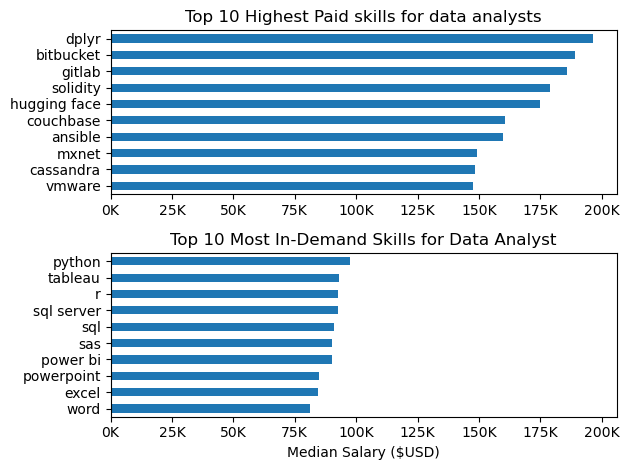

In [5]:
fig,ax = plt.subplots(2,1)

df_da_top_pay[::-1].plot(kind ='barh',y='median',ax=ax[0],legend = False)
ax[0].set_title('Top 10 Highest Paid skills for data analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f'{int(x/1000)}K'))


df_da_skills[::-1].plot(kind = 'barh', y='median',ax=ax[1],legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f'{int(x/1000)}K'))

fig.tight_layout()

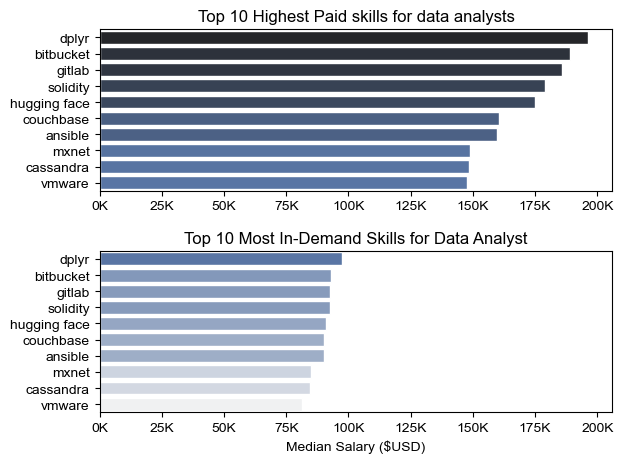

In [9]:
fig,ax = plt.subplots(2,1)

sns.set_theme(style='ticks')
# Top 10 highest paid skills for data analyst
sns.barplot(data=df_da_top_pay, x='median', y=df_da_top_pay.index, ax=ax[0], hue='median', palette='dark:b_r', legend=False)
ax[0].set_title('Top 10 Highest Paid skills for data analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f'{int(x/1000)}K'))

# top 10 mist in-demand skills for data analyst
sns.barplot(data=df_da_skills, x='median', y=df_da_top_pay.index, ax=ax[1], hue='median', palette='light:b', legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_ : f'{int(x/1000)}K'))

fig.tight_layout()

# Histograms


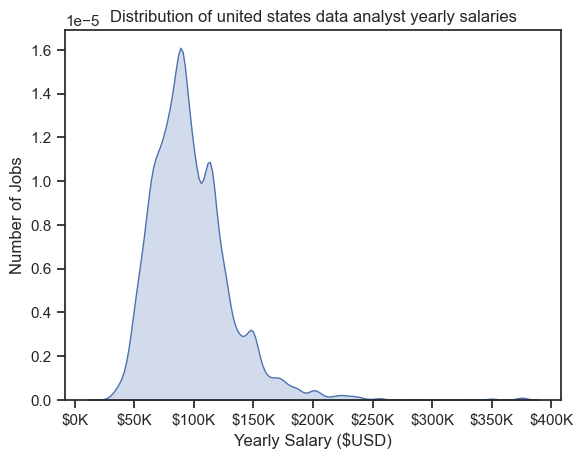

<Figure size 640x480 with 0 Axes>

In [25]:
sns.set_theme(style='ticks')
sns.kdeplot(df_da_us['salary_year_avg'], fill=True)
plt.title('Distribution of united states data analyst yearly salaries')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('Number of Jobs')
ax=plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
plt.show()
plt.tight_layout()

# Box Plots


(11818, 17)


C:\Users\HP\AppData\Local\Temp\ipykernel_17808\1738157268.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


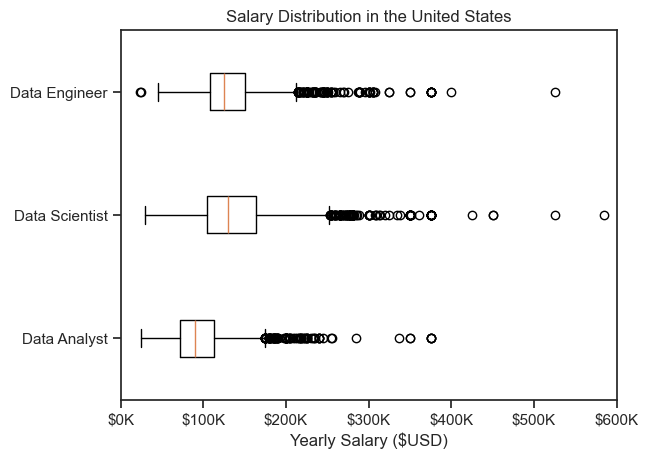

In [36]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_us = df[
    (df['job_title_short'].isin(job_titles)) &
    (df['job_country'] == 'United States')
].dropna(subset=['salary_year_avg'])

print(df_us.shape)  # always check this

job_list = [
    df_us[df_us['job_title_short'] == job_title]['salary_year_avg']
    for job_title in job_titles
]

plt.boxplot(job_list, labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.xlim(0, 600000)

ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

plt.show()

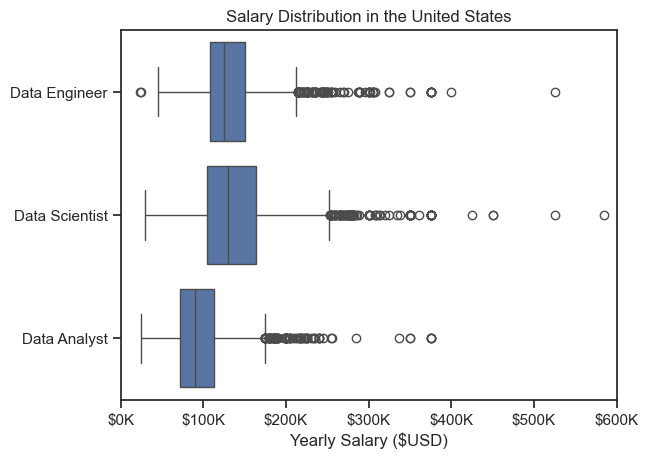

In [38]:
sns.boxplot(data=df_us, x='salary_year_avg', y='job_title_short')
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel("")
plt.xlim(0, 600000)

ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

plt.show()